# Чувствительность к β, c и γ
Полный факторный план: 3×3×3 сочетания, 10 повторов каждого.
Сетка и число повторов выбраны для дополнительного задания 1.
Одинаковые seed между сочетаниями облегчают сравнение, но после расхождения
траекторий не означают попарно совпадающие контакты.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
betas = [.03,.05,.07]
contacts = [5.0,10.0,15.0]
gammas = [.15,.25,.4]
repeats = 10
rows = NamedTuple[]
for beta in betas, c in contacts, gamma in gammas, rep in 1:repeats
    model, result = simulate(family="scan",p=[beta,c,gamma],seed=2000+rep)
    push!(rows,result)
end
runs = save_table("sensitivity-runs",DataFrame(rows));

## Средние показатели и межтраекторное стандартное отклонение
peak_sd описывает разброс пика, а не ошибку одного конкретного запуска.

In [3]:
summary = save_table("sensitivity-summary",summarize(runs,[:beta,:c,:gamma]))
display(select(summary,:beta,:c,:gamma,:peak_mean,:peak_sd,:peak_time_mean,:R_fraction_mean))

Row,beta,c,gamma,peak_mean,peak_sd,peak_time_mean,R_fraction_mean
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.03,5.0,0.15,17.3,5.69698,18.4613,0.0564
2,0.03,5.0,0.25,11.8,1.68655,1.19032,0.0235
3,0.03,5.0,0.4,10.4,0.966092,0.0931003,0.0165
4,0.03,10.0,0.15,173.2,23.541,28.4226,0.5515
5,0.03,10.0,0.25,38.9,17.7792,24.2014,0.2012
6,0.03,10.0,0.4,12.6,2.45855,1.24055,0.0241
7,0.03,15.0,0.15,307.6,16.3924,18.119,0.8846
8,0.03,15.0,0.25,146.1,26.5516,20.4025,0.7067
9,0.03,15.0,0.4,27.3,14.0163,16.447,0.1784


## Влияние β при c=10

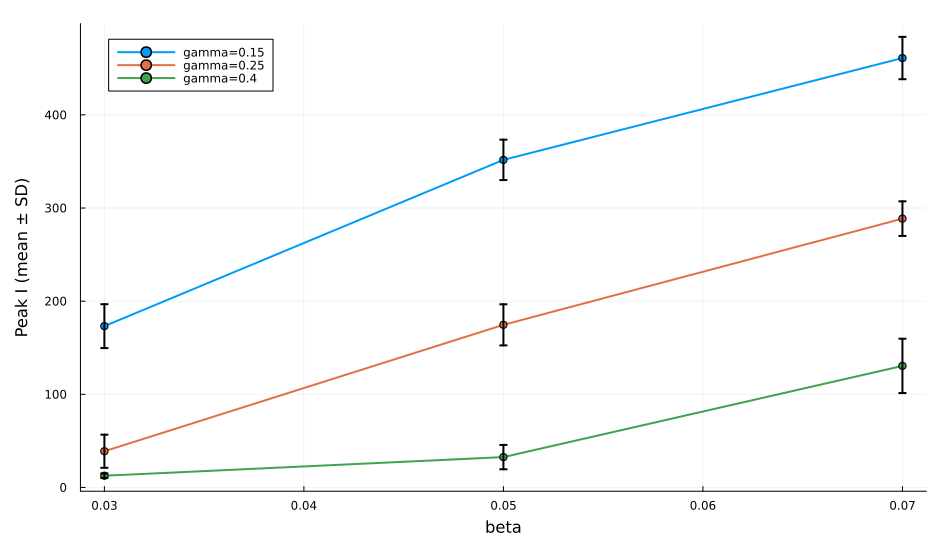

In [4]:
fig=plot(;xlabel="beta",ylabel="Peak I (mean ± SD)",size=(950,550))
for gamma in gammas
    part=sort(filter(r->r.c==10 && r.gamma==gamma,summary),:beta)
    plot!(fig,part.beta,part.peak_mean;yerror=part.peak_sd,marker=:circle,
        label="gamma=$(gamma)",lw=2)
end
savefig(fig,figure_path("02-plot"))
display(fig)

## Время пика и доля R(T)

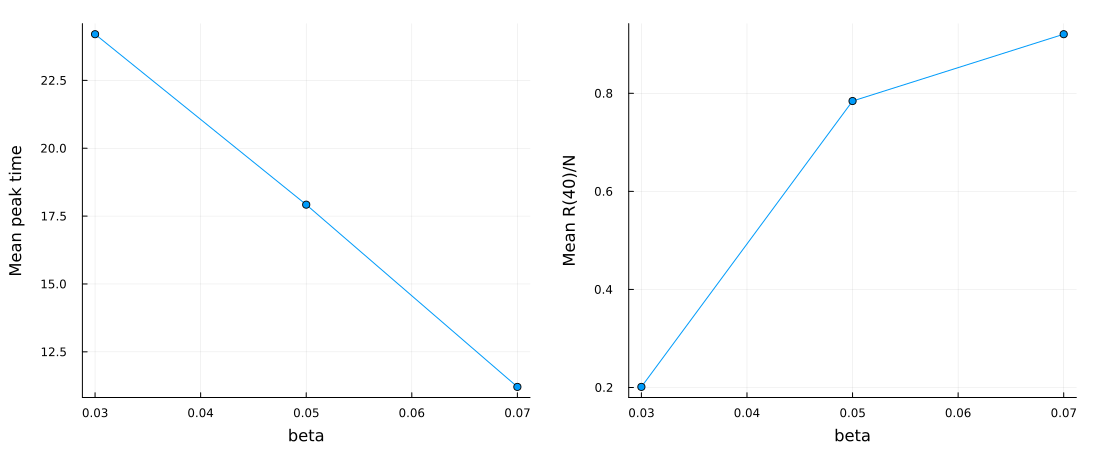

In [5]:
part=sort(filter(r->r.c==10 && r.gamma==.25,summary),:beta)
fig2=plot(plot(part.beta,part.peak_time_mean;marker=:circle,label=false,
    xlabel="beta",ylabel="Mean peak time"),
    plot(part.beta,part.R_fraction_mean;marker=:circle,label=false,
    xlabel="beta",ylabel="Mean R(40)/N");layout=(1,2),size=(1100,450))
savefig(fig2,figure_path("03-plot"))
display(fig2)